1.Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib # To save the model as .sav file

2.Data Cleaning

In [ ]:
# Loading the dataset
data = pd.read_csv('creditcard.csv')

# Checking for missing values
print(data.isnull().sum())

# Dropping missing values if any (usually not required for this dataset)
data = data.dropna()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaling the Amount column
data['Amount'] = scaler.fit_transform(data['Amount'].values.reshape(-1, 1))

# Scaling the Time column (Optional but better)
data['Time'] = scaler.fit_transform(data['Time'].values.reshape(-1, 1))

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


3.Data Visualization

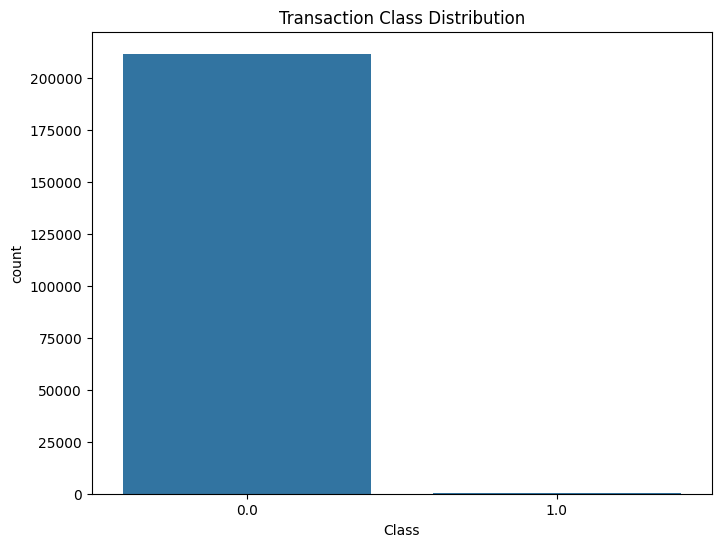

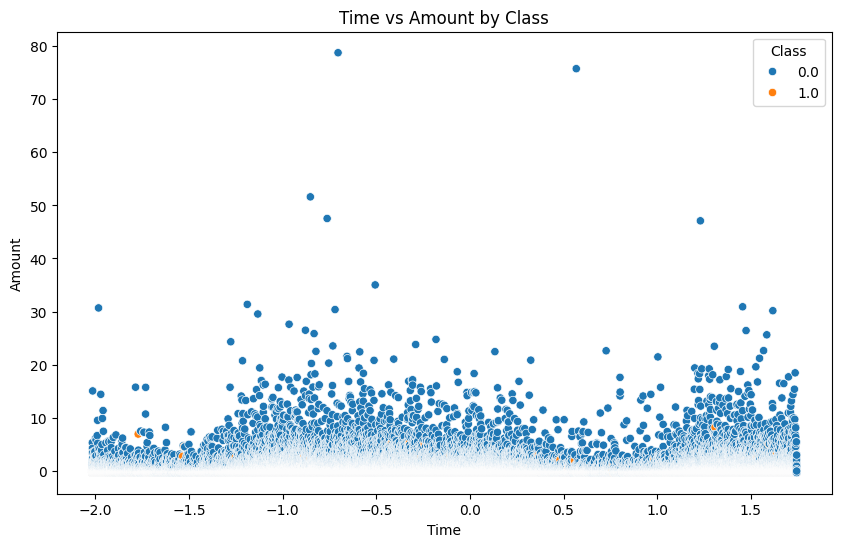

In [ ]:
# Plotting the distribution of Class (0: Normal, 1: Fraud)
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=data)
plt.title('Transaction Class Distribution')
plt.show()

# Time vs Amount distribution
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Time', y='Amount', hue='Class', data=data)
plt.title('Time vs Amount by Class')
plt.show()

4.Exploratory Data Analysis (EDA)

In [ ]:
# Statistical summary
print(data.describe())

# Checking the number of fraud and legitimate transactions
legit = data[data.Class == 0]
fraud = data[data.Class == 1]

print(f"Legit transactions: {legit.shape}")
print(f"Fraud transactions: {fraud.shape}")

# Comparing values for both transactions
print(data.groupby('Class').mean())

               Time             V1             V2             V3  \
count  2.119890e+05  211989.000000  211989.000000  211989.000000   
mean   1.544505e-16      -0.082445      -0.004056       0.255986   
std    1.000002e+00       1.909117       1.631398       1.467119   
min   -2.016392e+00     -56.407510     -72.715728     -33.680984   
25%   -7.751509e-01      -0.953502      -0.589129      -0.445880   
50%   -1.238392e-01      -0.058275       0.075326       0.437968   
75%    1.023253e+00       1.227442       0.781116       1.189327   
max    1.744763e+00       2.454930      22.057729       9.382558   

                  V4             V5             V6             V7  \
count  211989.000000  211989.000000  211989.000000  211989.000000   
mean        0.060506      -0.087392       0.040287      -0.038152   
std         1.404105       1.364221       1.315732       1.218486   
min        -5.683171     -42.147898     -26.160506     -43.557242   
25%        -0.807694      -0.766843      -

5.Data Modeling

In [ ]:
# Taking a random sample from legit transactions to match fraud count (492)
legit_sample = legit.sample(n=492)

# Concatenating two dataframes
new_dataset = pd.concat([legit_sample, fraud], axis=0)

print(new_dataset['Class'].value_counts())

Class
0.0    492
1.0    394
Name: count, dtype: int64


6.Splitting the Data into Features and Targets

In [ ]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

7.Splitting the Data into Test and Training Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

8.Model Training

In [ ]:

model = LogisticRegression(max_iter=1000)

# Training the model
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

9.Model Evaluation

In [ ]:
# Accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print(f'Accuracy on Training data: {training_data_accuracy}')

# Accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print(f'Accuracy on Test data: {test_data_accuracy}')

Accuracy on Training data: 0.9661016949152542
Accuracy on Test data: 0.9269662921348315


10.Communication and Visualization (Confusion Matrix)

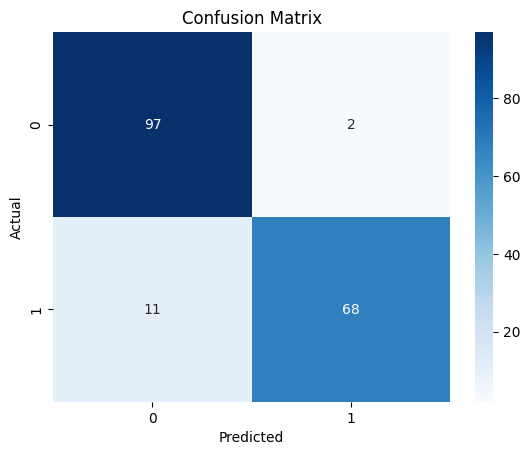

In [ ]:
conf_matrix = confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

11.Model Saving

In [ ]:
# Saving the model using joblib
filename = 'credit_card_model.sav'
joblib.dump(model, filename)
print(f"Model saved successfully as {filename}")

Model saved successfully as credit_card_model.sav
